# Analysis of capacity factor data

In [63]:
import sys
import os
import xarray as xr
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.colors as colors
import matplotlib.colorizer as mcolorizer
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [17]:
# START_YEAR = 1980
START_YEAR = 1980
END_YEAR = 2020

OUTPUT_DIR = '/g/data/nf33/nk2247/wind_droughts/GC26_energy_synoptics/dev/wind_drought/'

In [18]:
# Specify path of capacity factor data
cf_paths = [f'/g/data/w42/dr6273/work/projects/Aus_energy/production_metrics/wind/capacity_factor/van_der_Wiel/wind_capacity_factor_van_der_Wiel_era5_hourly_{year}_Aus.nc' for year in range(START_YEAR, END_YEAR+1)]

In [19]:
# Read capacity factor data
cf_ds = xr.open_mfdataset(
    cf_paths,
    chunks={"time": 365*5}
)

In [20]:
# Calculating instances where cf below threshold #
cf_below_10_percent = np.less(cf_ds['capacity_factor'], 0.1)
cf_below_20_percent = np.less(cf_ds['capacity_factor'], 0.2)

In [21]:
# Count instances where cf below threshold #
cf_below_10_percent_count = np.sum(cf_below_10_percent, axis=0)
cf_below_20_percent_count = np.sum(cf_below_20_percent, axis=0)

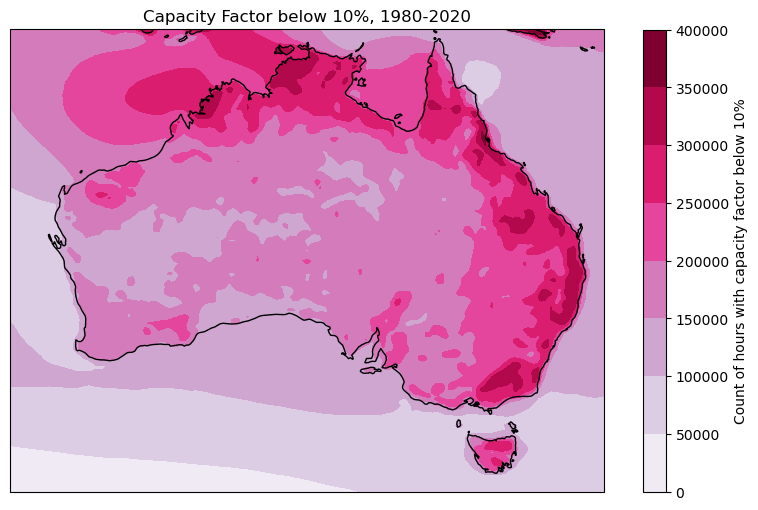

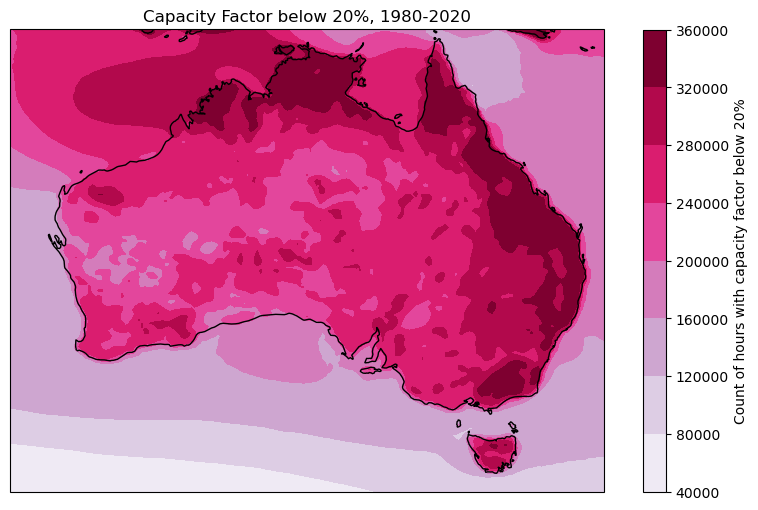

In [22]:
# Getting Lats/Lons #
lon_1d = cf_ds["lon"]
lat_1d = cf_ds["lat"]

lon_min, lon_max, lat_min, lat_max = lon_1d.min(), lon_1d.max(), lat_1d.min(), lat_1d.max()

# Making lat/lons into 2d grids #
lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)

# Plotting #
# Below 10% Map #
fig_below_10_percent = plt.figure(figsize=(10, 6))

# Map configuration #
ax1 = plt.axes(projection=ccrs.PlateCarree(central_longitude=134))
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features #
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.add_feature(cfeature.LAND, alpha=0.3)
ax1.add_feature(cfeature.OCEAN, alpha=0.2)

# Add title #
ax1.set_title(f"Capacity Factor below 10%, {START_YEAR}-{END_YEAR}")

cf1 = ax1.contourf(  
    lon2d,
    lat2d,
    cf_below_10_percent_count,
    cmap="PuRd",
    transform=ccrs.PlateCarree(),
    transform_first = True
)

cbar = plt.colorbar(cf1, location='right')
cbar.set_label("Count of hours with capacity factor below 10%")
fig_below_10_percent.savefig(OUTPUT_DIR + f'capacity_factor_below_10percent_hours_{START_YEAR}_{END_YEAR}.pdf')

# Below 20% Map #
fig_below_20_percent = plt.figure(figsize=(10, 6))

# Map configuration #
ax2 = plt.axes(projection=ccrs.PlateCarree(central_longitude=134))
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features #
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.add_feature(cfeature.LAND, alpha=0.3)
ax2.add_feature(cfeature.OCEAN, alpha=0.2)

# Add title #
ax2.set_title(f"Capacity Factor below 20%, {START_YEAR}-{END_YEAR}")

cf2 = ax2.contourf(  
    lon2d,
    lat2d,
    cf_below_20_percent_count,
    cmap="PuRd",
    transform=ccrs.PlateCarree(),
    transform_first = True
)

cbar = plt.colorbar(cf2, location='right')
cbar.set_label("Count of hours with capacity factor below 20%")
fig_below_20_percent.savefig(OUTPUT_DIR + f'capacity_factor_below_20percent_hours_{START_YEAR}_{END_YEAR}.pdf')

In [33]:
# Count fraction of days where cf below threshold #
num_records_per_grid = cf_ds['capacity_factor'].count(dim='time')
cf_below_10_percent_frac = cf_below_10_percent_count / num_records_per_grid
cf_below_20_percent_frac = cf_below_20_percent_count / num_records_per_grid

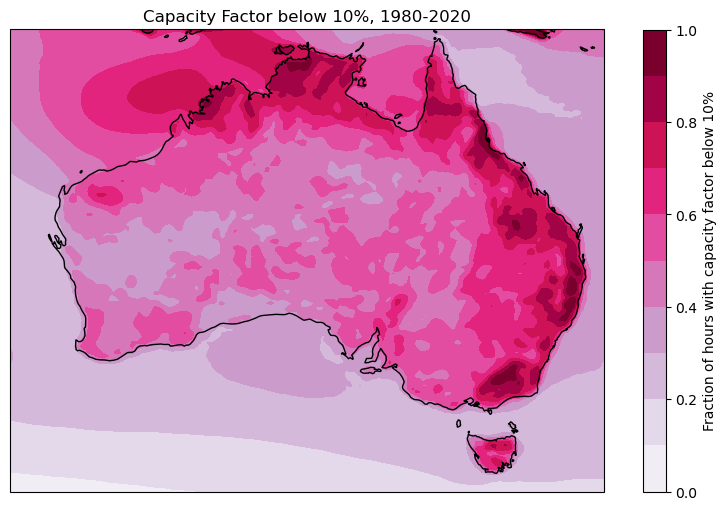

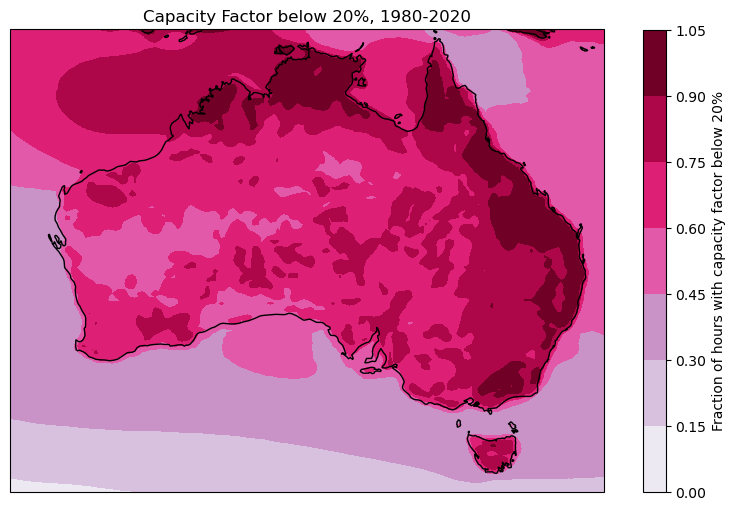

In [35]:
# Getting Lats/Lons #
lon_1d = cf_ds["lon"]
lat_1d = cf_ds["lat"]

lon_min, lon_max, lat_min, lat_max = lon_1d.min(), lon_1d.max(), lat_1d.min(), lat_1d.max()

# Making lat/lons into 2d grids #
lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)

# Plotting #
# Below 10% Map #
fig_below_10_percent = plt.figure(figsize=(10, 6))

# Map configuration #
ax1 = plt.axes(projection=ccrs.PlateCarree(central_longitude=134))
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features #
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.add_feature(cfeature.LAND, alpha=0.3)
ax1.add_feature(cfeature.OCEAN, alpha=0.2)

# Add title #
ax1.set_title(f"Capacity Factor below 10%, {START_YEAR}-{END_YEAR}")

cf1 = ax1.contourf(  
    lon2d,
    lat2d,
    cf_below_10_percent_frac,
    cmap="PuRd",
    transform=ccrs.PlateCarree(),
    transform_first = True,
    levels = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
)

cbar = plt.colorbar(cf1, location='right')
cbar.set_label("Fraction of hours with capacity factor below 10%")
fig_below_10_percent.savefig(OUTPUT_DIR + f'capacity_factor_below_10percent_fraction_hours_{START_YEAR}_{END_YEAR}.pdf')

# Below 20% Map #
fig_below_20_percent = plt.figure(figsize=(10, 6))

# Map configuration #
ax2 = plt.axes(projection=ccrs.PlateCarree(central_longitude=134))
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features #
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.add_feature(cfeature.LAND, alpha=0.3)
ax2.add_feature(cfeature.OCEAN, alpha=0.2)

# Add title #
ax2.set_title(f"Capacity Factor below 20%, {START_YEAR}-{END_YEAR}")

cf2 = ax2.contourf(  
    lon2d,
    lat2d,
    cf_below_20_percent_frac,
    cmap="PuRd",
    transform=ccrs.PlateCarree(),
    transform_first = True,
    levels = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
)

cbar = plt.colorbar(cf2, location='right')
cbar.set_label("Fraction of hours with capacity factor below 20%")
fig_below_20_percent.savefig(OUTPUT_DIR + f'capacity_factor_below_20percent_fraction_hours_{START_YEAR}_{END_YEAR}.pdf')

## Hourly breakdown

In [56]:
# Check which hours they occur most often in
cf_below_10_percent_frac_hourly = {}
for hour, cf_ds_hour in cf_ds['capacity_factor'].groupby('time.hour'): 
    # Find instances where cf is below threshold #
    cf_below_10_percent = np.less(cf_ds_hour, 0.1)
    
    # Count instances where cf below threshold #
    cf_below_10_percent_count = np.sum(cf_below_10_percent, axis=0)
    
    # Count fraction of hours where cf below threshold #
    num_records_per_grid = cf_ds_hour.count(dim='time')
    cf_below_10_percent_frac_hourly[hour] = cf_below_10_percent_count / num_records_per_grid


In [ ]:
# Check hourly occurences
# Getting Lats/Lons #
lon_1d = cf_ds["lon"]
lat_1d = cf_ds["lat"]

lon_min, lon_max, lat_min, lat_max = lon_1d.min(), lon_1d.max(), lat_1d.min(), lat_1d.max()

# Making lat/lons into 2d grids #
lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)

# Plotting #
# Below 10% Map #
fig_below_10_percent, axes = plt.subplots(figsize=(20, 12), nrows=4, ncols=6, subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=134)))

for hour, ax in enumerate(axes.flatten(), start=0):
    # Map configuration #
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # Add map features #
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.3)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    
    cf1 = ax.contourf(  
        lon2d,
        lat2d,
        cf_below_10_percent_frac_hourly[hour],
        cmap="PuRd",
        transform=ccrs.PlateCarree(),
        transform_first = True,
        levels = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
    )
    ax.set_title(f'Hour = {hour}')

cbar = plt.colorbar(cf1, location='right')
cbar.set_label("Fraction of hours with capacity factor below 10%")
# Add title #
fig_below_10_percent.suptitle(f"Capacity Factor below 10%, {START_YEAR}-{END_YEAR}")
fig_below_10_percent.savefig(OUTPUT_DIR + f'capacity_factor_below_10percent_hours_hourly_{START_YEAR}_{END_YEAR}.pdf', bbox_extra_artists = [cbar], bbox='tight')

## Monthly breakdown

In [50]:
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

In [53]:
cf_below_10_percent_frac_monthly = {}
for month, cf_ds_month in cf_ds['capacity_factor'].groupby('time.month'): 
    # Find instances where cf is below threshold #
    cf_below_10_percent = np.less(cf_ds_month, 0.1)
    
    # Count instances where cf below threshold #
    cf_below_10_percent_count = np.sum(cf_below_10_percent, axis=0)
    
    # Count fraction of hours where cf below threshold #
    num_records_per_grid = cf_ds_month.count(dim='time')
    cf_below_10_percent_frac_monthly[month] = cf_below_10_percent_count / num_records_per_grid


In [ ]:
# Check seasonality
# Getting Lats/Lons #
lon_1d = cf_ds["lon"]
lat_1d = cf_ds["lat"]

lon_min, lon_max, lat_min, lat_max = lon_1d.min(), lon_1d.max(), lat_1d.min(), lat_1d.max()

# Making lat/lons into 2d grids #
lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)

# Plotting #
# Below 10% Map #
fig_below_10_percent, axes = plt.subplots(figsize=(20, 12), nrows=3, ncols=4, subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=134)))

norm = colors.Normalize(vmin=0, vmax=1)
colorizer = mcolorizer.Colorizer(cmap='PuRd', norm=norm)

for month, ax in enumerate(axes.flatten(), start=1):
    # Map configuration #
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # Add map features #
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.3)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    
    ax.set_title(month_names[month])

    cf1 = ax.contourf(  
        lon2d,
        lat2d,
        cf_below_10_percent_frac_monthly[month],
        colorizer=colorizer,
        transform=ccrs.PlateCarree(),
        transform_first = True,
        levels = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
    )

cbar = fig_below_10_percent.colorbar(cf1,location='right',orientation='vertical', cax=plt.axes((0.95, 0.1, 0.05, 0.8)))
cbar.set_label("Fraction of hours with capacity factor below 10%")

# Add title #
fig_below_10_percent.suptitle(f"Capacity Factor below 10%, {START_YEAR}-{END_YEAR}")
fig_below_10_percent.savefig(OUTPUT_DIR + f'capacity_factor_below_10percent_hours_monthly_{START_YEAR}_{END_YEAR}.pdf', bbox_extra_artists = [cbar], bbox='tight')

Text(0.5, 0.98, 'Capacity Factor below 10%, 1980-2020')

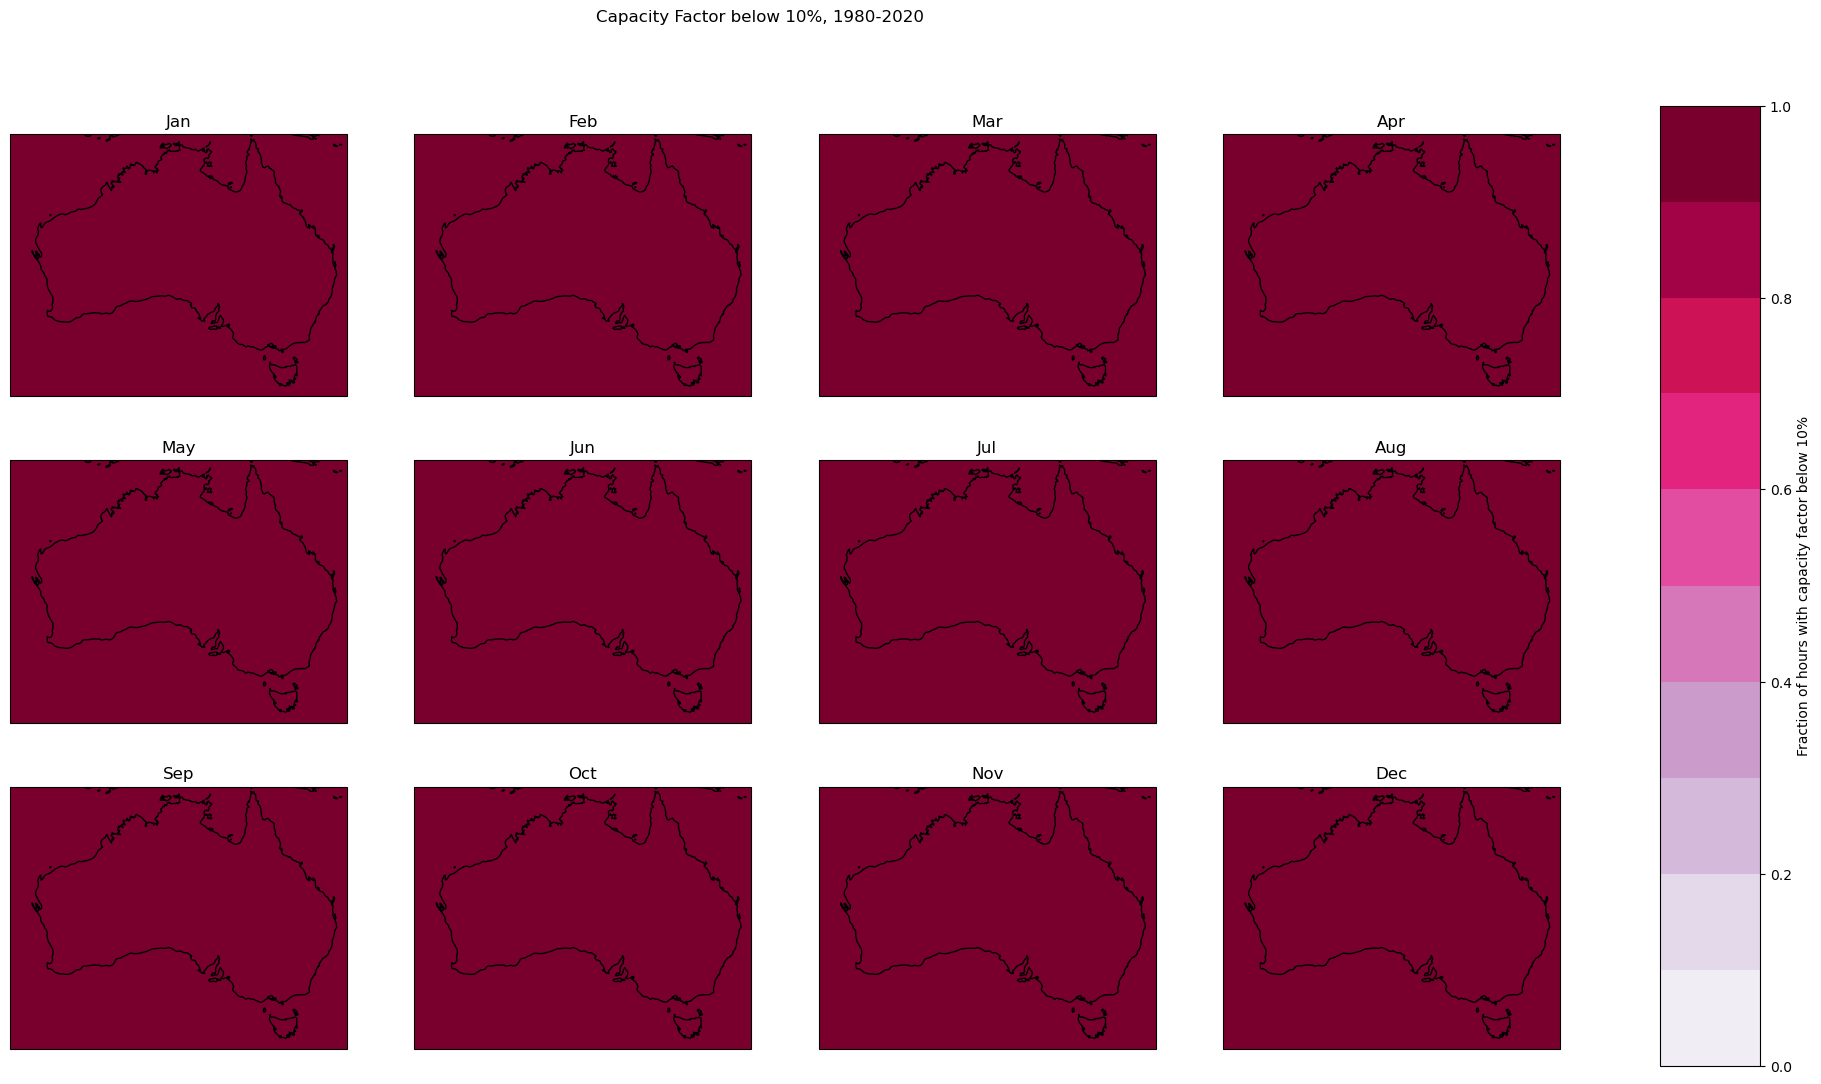

In [88]:
# Check seasonality
# Getting Lats/Lons #
lon_1d = cf_ds["lon"]
lat_1d = cf_ds["lat"]

lon_min, lon_max, lat_min, lat_max = lon_1d.min(), lon_1d.max(), lat_1d.min(), lat_1d.max()

# Making lat/lons into 2d grids #
lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)

# Plotting #
# Below 10% Map #
fig_below_10_percent, axes = plt.subplots(figsize=(20, 12), nrows=3, ncols=4, subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=134)))

norm = colors.Normalize(vmin=0, vmax=1)
colorizer = mcolorizer.Colorizer(cmap='PuRd', norm=norm)

for month, ax in enumerate(axes.flatten(), start=1):
    # Map configuration #
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # Add map features #
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.3)
    ax.add_feature(cfeature.OCEAN, alpha=0.2)
    
    ax.set_title(month_names[month])
    
    cf1 = ax.contourf(  
        lon2d,
        lat2d,
        np.ones_like(lon2d),
        colorizer=colorizer,
        transform=ccrs.PlateCarree(),
        transform_first = True,
        levels = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
    )

cbar = fig_below_10_percent.colorbar(cf1,location='right',orientation='vertical', cax=plt.axes((0.95, 0.1, 0.05, 0.8)))
cbar.set_label("Fraction of hours with capacity factor below 10%")

# Add title #
fig_below_10_percent.suptitle(f"Capacity Factor below 10%, {START_YEAR}-{END_YEAR}")
# fig_below_10_percent.savefig(OUTPUT_DIR + f'capacity_factor_below_10percent_hours_monthly_{START_YEAR}_{END_YEAR}.pdf')

In [ ]:
# Compare to regimes -> Which regime drives low capacity or not